# **EDA: ANÁLISIS EXPLORATORIO DE DATOS**

Este notebook contiene la revisión exploratoria inicial de los datasets originales, con el objetivo de evaluar su estructura, calidad y estado general antes de aplicar cualquier proceso de limpieza o transformación.

La revisión se realiza mediante una función estructurada que centraliza la validación del dataset y permite identificar posibles problemas de calidad de datos, inconsistencias y características relevantes para su posterior preparación.

In [1]:
# ============================================================================
# CONFIGURACIÓN DEL ENTORNO
# Importación de librerías para la manipulación, análisis y visualización
# de datos durante la fase exploratoria (EDA).
# ============================================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN EN PANDAS
# Ajuste de opciones para mejorar la legibilidad durante la inspección
# exploratoria, mostrando todas las columnas y un número acotado de filas.
# ============================================================================

pd.set_option("display.max_columns", None)  # mostrar todas las columnas
pd.set_option("display.max_rows", 100)      # limitar la visualización de filas
pd.set_option("display.width", None)        # ajustar automáticamente el ancho


# ============================================================================
# CARGA DE LOS DATASETS
# Se cargan los datasets originales desde data/raw manteniéndolos en su estado
# original (sin modificaciones) para el análisis inicial.
# ============================================================================

path_df1 = "../data/raw/dating_apps_espana_completo_2026.csv"
path_df2 = "../data/raw/DatingAppReviewsDataset.csv"

df1 = pd.read_csv(path_df1, index_col=0)
df2 = pd.read_csv(path_df2,index_col=0)


# ============================================================================
# INSPECCIÓN INICIAL
# Visualización de las primeras filas para verificar la correcta carga,
# estructura general y nombres de columnas.
# ============================================================================

display(df1.head())
display(df2.head())


,genero,edad,ccaa,app_principal,nivel_estudios,nivel_ingresos,orientacion_sexual,minutos_mes,horas_mes,dias_activos_mes,sesiones_por_dia,minutos_por_sesion,frecuencia_semanal,swipes_diarios,swipes_mes,likes_enviados_diarios,likes_enviados_mes,likes_recibidos_mes,ratio_likes_enviados_recibidos,matches_mes,conversaciones_enviadas_mes,respuestas_recibidas_mes,calidad_match,tasa_exito_match,matches_por_hora,conversion_conversacion,tasa_respuesta,indice_reciprocidad,tasa_conversion_cita,eficiencia_funnel,envio_mensaje,hizo_ghosting,realizo_cita,perfil_usuario,score_atractivo
id_usuario,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Hombre,31,Madrid,Grindr,Universitario,Medio,Gay,501,8.35,14,7.3,4.9,3,22,308,14,196,4,49.00,1,0,1,0.0051,0.0032,0.120,0.0000,0.0,0.0000,0.0,0.0,No,No,No,Pasivo,-2.09
2,Mujer,49,Cataluña,Grindr,Universitario,Medio,LGBTQ+,689,11.48,18,1.0,38.3,4,19,342,10,180,93,1.94,14,10,5,0.0778,0.0409,1.220,0.7143,0.5,0.0389,0.0,0.0,Sí,No,No,Conversador,-0.09
3,Mujer,31,Aragón,Tinder,Primarios,Medio,Heterosexual,107,1.78,2,3.5,15.3,2,41,82,28,56,8,7.00,0,0,0,0.0000,0.0000,0.000,0.0000,0.0,0.0000,0.0,0.0,No,No,No,Selectivo,-0.44
4,Hombre,48,Galicia,Grindr,Secundario,Medio-Alto,Gay,309,5.15,16,2.0,9.7,4,22,352,12,192,14,13.71,0,0,0,0.0000,0.0000,0.000,0.0000,0.0,0.0000,0.0,0.0,No,No,No,Pasivo,0.56
5,Hombre,27,Cataluña,Badoo,Secundario,Alto,Heterosexual,183,3.05,10,4.7,3.9,2,31,310,18,180,10,18.00,2,2,2,0.0111,0.0065,0.656,1.0000,1.0,0.0111,0.0,0.0,Sí,No,No,Conversador,0.36


,Name,Review,Rating,#ThumbsUp,Date&Time,App
0,linah sibanda,On this app i cant find a partner,5,0,18-02-2022 01:19,Tinder
1,Norman Johnson,Tinder would be so much better if we could spe...,3,0,18-02-2022 01:16,Tinder
2,David Hume,Still doesn't correctly notify matches or mess...,1,0,18-02-2022 01:11,Tinder
3,Last 1 Standing,"Got banned because I updated my bio to say ""I ...",2,0,18-02-2022 01:11,Tinder
4,Arthur Magamedov,Love it!,5,0,18-02-2022 01:06,Tinder


In [2]:
def eda(df):
    """
    Realiza un análisis exploratorio estructurado (EDA) sobre un DataFrame.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset a analizar.

    Devuelve
    --------
    None
        La función no devuelve ningún objeto. Muestra en pantalla el análisis
        exploratorio, estadísticas descriptivas, visualizaciones y flags de calidad.

    Qué analiza
    -----------
    1) Visión general:
       - Vista inicial (head), dimensiones, info() y duplicados.

    2) Calidad de columnas:
       - Tabla resumen por columna (tipos, nulos, cardinalidad).
       - Flags por umbral de nulos (bajo/moderado/alto).

    3) Análisis de nulos:
       - Categóricas: distribución (porcentaje + recuento) incluyendo NaN.
       - Numéricas: % nulos + histograma + KDE (si aplica) + media/mediana/moda.

    4) Estadística descriptiva y controles básicos:
       - Describe numéricas y categóricas.
       - Flags: valores negativos en numéricas; varianza 0 en numéricas.

    5) Outliers:
       - Detección por IQR (1.5x) + boxplot para columnas con outliers.

    Objetivo
    --------
    Facilitar decisiones de limpieza (imputación, tipado, tratamiento de outliers)
    y comprensión del dataset antes de aplicar transformaciones.
    """

    # ==================================================
    # 1) VISIÓN GENERAL
    # ==================================================
    # Objetivo: obtener una primera fotografía del dataset (tamaño, estructura,
    # tipos básicos y presencia de duplicados) antes de entrar en métricas y flags.
    print("📐 VISIÓN GENERAL DEL DATASET")
    print("Vista inicial (primeras 5 filas):")
    display(df.head())

    filas, columnas = df.shape
    print(f"Dimensiones: {filas} filas × {columnas} columnas")

    print("\nInformación general (dtypes, nulos, memoria):")
    df.info()

    duplicados = df.duplicated().sum()
    pct_dup = (duplicados / filas * 100) if filas else 0
    print(f"\n🚩 FLAG: duplicados - Filas duplicadas: {duplicados} ({pct_dup:.2f}%)")
    print("-" * 70)

    # ==================================================
    # 2) CALIDAD DE COLUMNAS
    # ==================================================
    # Objetivo: construir una tabla resumen por columna para identificar
    # rápidamente variables problemáticas (nulos, tipos).
    print("🚑 CALIDAD DE COLUMNAS")

    calidad = (
        pd.DataFrame({
            "Tipo": df.dtypes,
            "Nulos": df.isnull().sum(),
            "% Nulos": (df.isnull().mean() * 100).round(2),
            "Valores Únicos": df.nunique(),
            "% Cardinalidad": (df.nunique()/filas*100).round(2)
            })
        .sort_values("% Nulos", ascending=False)
    )

    display(calidad)

    # ---- Flags por nulos (umbrales) ----
    # Objetivo: priorizar el tratamiento de nulos clasificando columnas según severidad.
    cols_nulos_bajo = calidad[(calidad["% Nulos"] > 0) & (calidad["% Nulos"] <= 5)].index.tolist()
    cols_nulos_moderado = calidad[(calidad["% Nulos"] > 5) & (calidad["% Nulos"] <= 20)].index.tolist()
    cols_nulos_alto = calidad[calidad["% Nulos"] > 20].index.tolist()

    print("\n🚩 FLAG: nulos - Clasificación por umbral (% nulos)")
    print("  🟢 Bajo (≤ 5%):")
    if cols_nulos_bajo:
        for col in cols_nulos_bajo:
            print(f"    - {col} ({calidad.loc[col, '% Nulos']:.2f}%)")
    else:
        print("    - Ninguna")

    print("  🟡 Moderado (5%–20%):")
    if cols_nulos_moderado:
        for col in cols_nulos_moderado:
            print(f"    - {col} ({calidad.loc[col, '% Nulos']:.2f}%)")
    else:
        print("    - Ninguna")

    print("  🔴 Alto (> 20%):")
    if cols_nulos_alto:
        for col in cols_nulos_alto:
            print(f"    - {col} ({calidad.loc[col, '% Nulos']:.2f}%)")
    else:
        print("    - Ninguna")

    # ==================================================
    # 3) ANÁLISIS DE NULOS
    # ==================================================
    # Objetivo: identificar variables con nulos y entender el patrón básico:
    # - En categóricas: distribución de categorías + NaN.
    # - En numéricas: impacto de nulos y forma de la distribución para orientar imputación.

    # --- 3.1 Nulos en categóricas ---
    cols_cat = df.select_dtypes(include=["O"]).columns
    cols_cat_nulos = [c for c in cols_cat if df[c].isnull().any()]

    print("\n🔤 NULOS EN VARIABLES CATEGÓRICAS")
    if cols_cat_nulos:
        for col in cols_cat_nulos:
            pct_nulos = df[col].isnull().mean() * 100
            print(f"\n📌 {col} — 🚩 FLAG: nulos_categorica ({pct_nulos:.2f}%)")

            dist_pct = df[col].value_counts(normalize=True, dropna=False) * 100
            dist_cnt = df[col].value_counts(dropna=False)

            display(pd.DataFrame({
                "Porcentaje": dist_pct.round(2),
                "Recuento": dist_cnt
            }))
    else:
        print("No hay variables categóricas con nulos.")



    # --- 3.2 Nulos en numéricas ---
    num_cols = df.select_dtypes(include=["number"]).columns
    cols_num_nulos = [c for c in num_cols if df[c].isnull().any()]

    print("\n📊 NULOS EN VARIABLES NUMÉRICAS")
    if cols_num_nulos:
        for col in cols_num_nulos:
            pct_nulos = df[col].isnull().mean() * 100
            print(f"\n📌 {col} — 🚩 FLAG: nulos_numerica ({pct_nulos:.2f}%)")

            plt.figure(figsize=(6, 4))
            s = pd.to_numeric(df[col], errors="coerce").dropna()

            # Histograma en densidad para comparar con KDE si aplica
            s.hist(bins=30, density=True, alpha=0.6)

            # KDE solo si hay suficientes datos y variabilidad
            if (len(s) >= 20) and (s.nunique() > 1) and (s.std() > 0):
                try:
                    s.plot(kind="kde", linewidth=2)
                except Exception:
                    pass

            media = s.mean()
            mediana = s.median()
            moda = s.mode()[0]

            plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.2f}")
            plt.axvline(mediana, color="green", linestyle="--", label=f"Mediana: {mediana:.2f}")
            if not np.isnan(moda):
                plt.axvline(moda, color="blue", linestyle="--", label=f"Moda: {moda:.2f}")

            plt.title(f"Distribución de {col}")
            plt.xlabel(col)
            plt.ylabel("Densidad")
            plt.legend()
            plt.show()
    else:
        print("No hay variables numéricas con nulos.")

    # ==================================================
    # 4) ESTADÍSTICAS DESCRIPTIVAS + FLAGS BÁSICAS
    # ==================================================
    # Objetivo: describir numéricas/categóricas y detectar incoherencias claras
    # (negativos y varianza 0) que suelen indicar errores o variables sin valor.
    print("\n📊 ESTADÍSTICAS DESCRIPTIVAS — NUMÉRICAS")
    if len(num_cols) > 0:
        display(df[num_cols].describe().T)

        cols_negativos = df[num_cols].columns[df[num_cols].min() < 0].tolist()
        cols_var_0 = df[num_cols].columns[df[num_cols].var() == 0].tolist()

        if cols_negativos:
            print("\n🚩 FLAG: rango - Valores negativos detectados en variables numéricas")
            for col in cols_negativos:
                min_val = df[col].min()
                print(f"  - {col} (mínimo: {min_val})")
        else:
            print("\n✅ No se detectaron valores negativos en variables numéricas.")

        if cols_var_0:
            print("\n🚩 FLAG: varianza - Variables con varianza 0 (sin variabilidad)")
            for col in cols_var_0:
                print(f"  - {col}")
        else:
            print("\n✅ No se detectaron variables con varianza 0.")
    else:
        print("No hay variables numéricas para describir.")

    print("\n🔤 ESTADÍSTICAS DESCRIPTIVAS — CATEGÓRICAS")
    if len(cols_cat) > 0:
        display(df[cols_cat].describe().T)
    else:
        print("No hay variables categóricas para describir.")

    # ==================================================
    # 4.1) MUESTRA DE CATEGORÍAS ÚNICAS (TOP N)
    # ==================================================
    # Objetivo: validar formato y consistencia de variables categóricas mostrando
    # una muestra acotada.
    print("\n📝 MUESTRA DE CATEGORÍAS (TOP 10) — VARIABLES CATEGÓRICAS")
    if len(cols_cat) > 0:
        for col in cols_cat:
            n_unique = df[col].nunique(dropna=False)
            print(f"\n📌 {col} — {n_unique} valores únicos (mostrando hasta 10)")
            valores = pd.Series(df[col].dropna().unique()).head(10)
            display(pd.DataFrame(valores, columns=["Valor (muestra)"]))
    else:
        print("No hay variables categóricas.")

    # ==================================================
    # 5) OUTLIERS (IQR)
    # ==================================================
    # Objetivo: detectar valores atípicos con IQR (1.5x) como señal para posibles
    # transformaciones, winsorización o tratamiento específico en limpieza.
    print("\n⚠️ OUTLIERS — Método IQR (1.5x)")
    if len(num_cols) > 0:
        for col in num_cols:
            s = pd.to_numeric(df[col], errors="coerce").dropna()
            if s.empty:
                continue

            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            if iqr == 0:
                continue

            limite_inferior = q1 - 1.5 * iqr
            limite_superior = q3 + 1.5 * iqr
            outliers = ((s < limite_inferior) | (s > limite_superior)).sum()

            if outliers > 0:
                pct_out = outliers / len(s) * 100
                print(f"🚩 FLAG: outliers - {col}: {outliers} ({pct_out:.2f}%)")

                media = s.mean()
                moda = s.mode()[0]

                plt.figure(figsize=(6, 2))
                sns.boxplot(x=s)
                plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.2f}")
                if not np.isnan(moda):
                    plt.axvline(moda, color="blue", linestyle="--", label=f"Moda: {moda:.2f}")
                plt.title(f"Boxplot de {col}")
                plt.legend()
                plt.show()
    else:
        print("No hay variables numéricas para análisis de outliers.")

    print("\n🏁 REVISIÓN EDA FINALIZADA")


📐 VISIÓN GENERAL DEL DATASET
Vista inicial (primeras 5 filas):


,genero,edad,ccaa,app_principal,nivel_estudios,nivel_ingresos,orientacion_sexual,minutos_mes,horas_mes,dias_activos_mes,sesiones_por_dia,minutos_por_sesion,frecuencia_semanal,swipes_diarios,swipes_mes,likes_enviados_diarios,likes_enviados_mes,likes_recibidos_mes,ratio_likes_enviados_recibidos,matches_mes,conversaciones_enviadas_mes,respuestas_recibidas_mes,calidad_match,tasa_exito_match,matches_por_hora,conversion_conversacion,tasa_respuesta,indice_reciprocidad,tasa_conversion_cita,eficiencia_funnel,envio_mensaje,hizo_ghosting,realizo_cita,perfil_usuario,score_atractivo
id_usuario,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Hombre,31,Madrid,Grindr,Universitario,Medio,Gay,501,8.35,14,7.3,4.9,3,22,308,14,196,4,49.00,1,0,1,0.0051,0.0032,0.120,0.0000,0.0,0.0000,0.0,0.0,No,No,No,Pasivo,-2.09
2,Mujer,49,Cataluña,Grindr,Universitario,Medio,LGBTQ+,689,11.48,18,1.0,38.3,4,19,342,10,180,93,1.94,14,10,5,0.0778,0.0409,1.220,0.7143,0.5,0.0389,0.0,0.0,Sí,No,No,Conversador,-0.09
3,Mujer,31,Aragón,Tinder,Primarios,Medio,Heterosexual,107,1.78,2,3.5,15.3,2,41,82,28,56,8,7.00,0,0,0,0.0000,0.0000,0.000,0.0000,0.0,0.0000,0.0,0.0,No,No,No,Selectivo,-0.44
4,Hombre,48,Galicia,Grindr,Secundario,Medio-Alto,Gay,309,5.15,16,2.0,9.7,4,22,352,12,192,14,13.71,0,0,0,0.0000,0.0000,0.000,0.0000,0.0,0.0000,0.0,0.0,No,No,No,Pasivo,0.56
5,Hombre,27,Cataluña,Badoo,Secundario,Alto,Heterosexual,183,3.05,10,4.7,3.9,2,31,310,18,180,10,18.00,2,2,2,0.0111,0.0065,0.656,1.0000,1.0,0.0111,0.0,0.0,Sí,No,No,Conversador,0.36


Dimensiones: 50000 filas × 35 columnas

Información general (dtypes, nulos, memoria):
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1 to 50000
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   genero                          50000 non-null  object 
 1   edad                            50000 non-null  int64  
 2   ccaa                            50000 non-null  object 
 3   app_principal                   50000 non-null  object 
 4   nivel_estudios                  50000 non-null  object 
 5   nivel_ingresos                  50000 non-null  object 
 6   orientacion_sexual              50000 non-null  object 
 7   minutos_mes                     50000 non-null  int64  
 8   horas_mes                       50000 non-null  float64
 9   dias_activos_mes                50000 non-null  int64  
 10  sesiones_por_dia                50000 non-null  float64
 11  minutos_por_

,Tipo,Nulos,% Nulos,Valores Únicos,% Cardinalidad
genero,object,0,0.0,2,0.00
edad,int64,0,0.0,46,0.09
ccaa,object,0,0.0,17,0.03
app_principal,object,0,0.0,10,0.02
nivel_estudios,object,0,0.0,4,0.01
nivel_ingresos,object,0,0.0,4,0.01
orientacion_sexual,object,0,0.0,4,0.01
minutos_mes,int64,0,0.0,1164,2.33
horas_mes,float64,0,0.0,1164,2.33
dias_activos_mes,int64,0,0.0,30,0.06



🚩 FLAG: nulos - Clasificación por umbral (% nulos)
  🟢 Bajo (≤ 5%):
    - Ninguna
  🟡 Moderado (5%–20%):
    - Ninguna
  🔴 Alto (> 20%):
    - Ninguna

🔤 NULOS EN VARIABLES CATEGÓRICAS
No hay variables categóricas con nulos.

📊 NULOS EN VARIABLES NUMÉRICAS
No hay variables numéricas con nulos.

📊 ESTADÍSTICAS DESCRIPTIVAS — NUMÉRICAS


...


📌 realizo_cita — 2 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,No
1,Sí



📌 perfil_usuario — 4 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,Pasivo
1,Conversador
2,Selectivo
3,Eficiente



⚠️ OUTLIERS — Método IQR (1.5x)
🚩 FLAG: outliers - edad: 403 (0.81%)


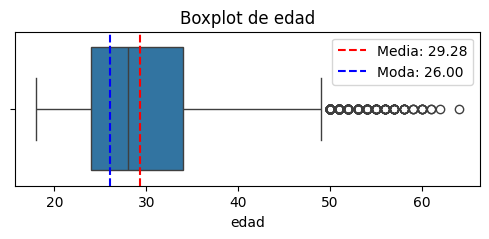

🚩 FLAG: outliers - minutos_mes: 6267 (12.53%)


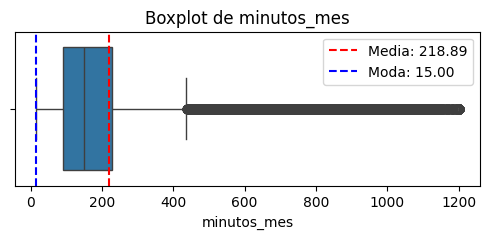

🚩 FLAG: outliers - horas_mes: 6267 (12.53%)


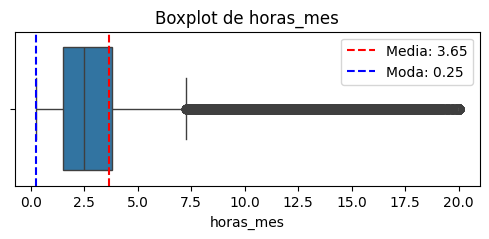

🚩 FLAG: outliers - dias_activos_mes: 3640 (7.28%)


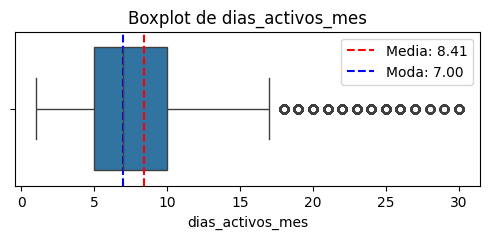

🚩 FLAG: outliers - sesiones_por_dia: 1626 (3.25%)


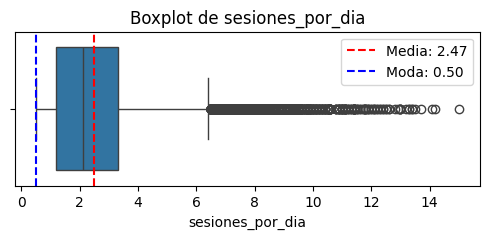

🚩 FLAG: outliers - minutos_por_sesion: 4030 (8.06%)


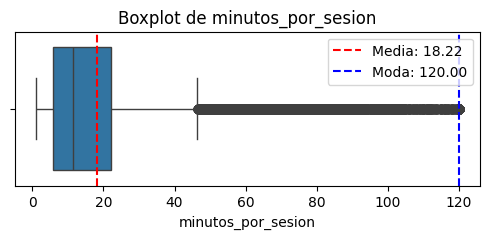

🚩 FLAG: outliers - swipes_diarios: 1429 (2.86%)


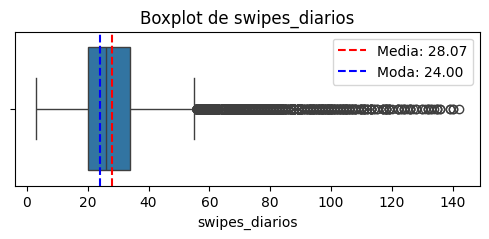

🚩 FLAG: outliers - swipes_mes: 4302 (8.60%)


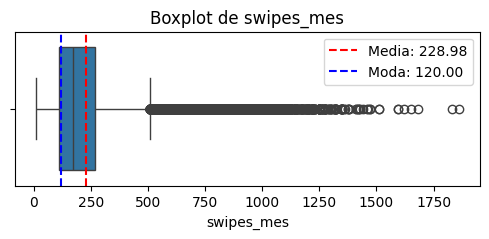

🚩 FLAG: outliers - likes_enviados_diarios: 1894 (3.79%)


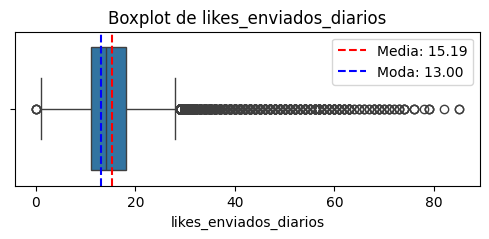

🚩 FLAG: outliers - likes_enviados_mes: 4426 (8.85%)


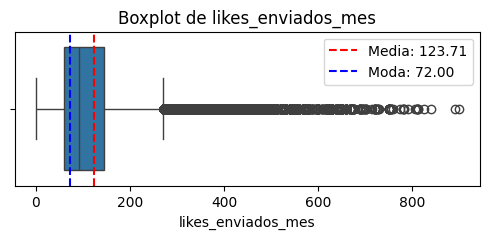

🚩 FLAG: outliers - likes_recibidos_mes: 6224 (12.45%)


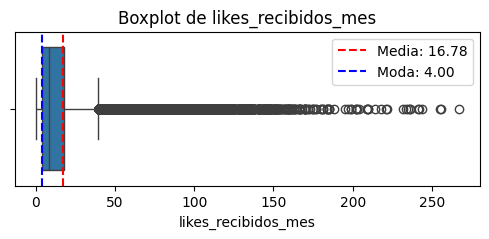

🚩 FLAG: outliers - matches_mes: 5009 (10.02%)


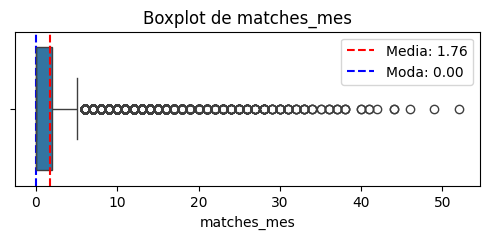

🚩 FLAG: outliers - conversaciones_enviadas_mes: 7203 (14.41%)


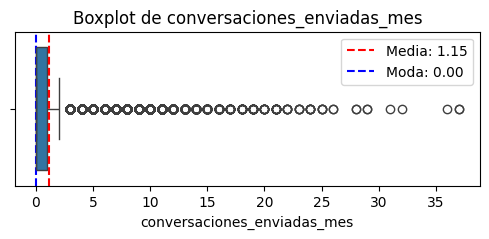

🚩 FLAG: outliers - respuestas_recibidas_mes: 7006 (14.01%)


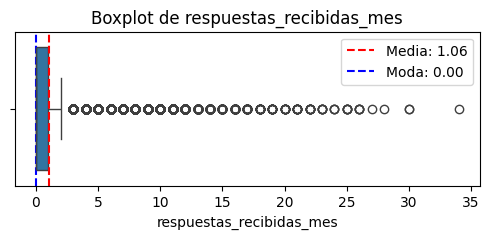

🚩 FLAG: outliers - calidad_match: 6894 (13.79%)


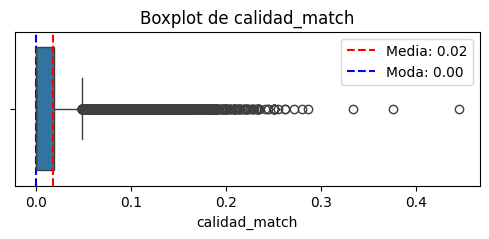

🚩 FLAG: outliers - tasa_exito_match: 6954 (13.91%)


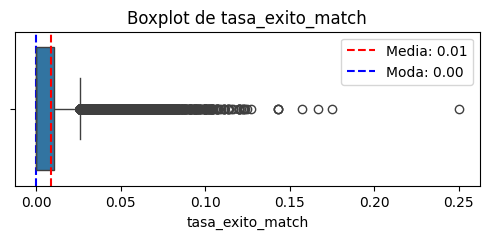

🚩 FLAG: outliers - matches_por_hora: 7015 (14.03%)


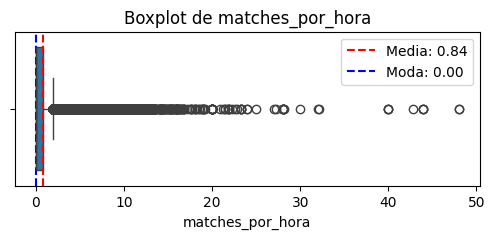

🚩 FLAG: outliers - indice_reciprocidad: 9148 (18.30%)


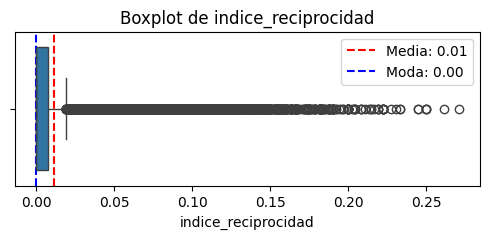

🚩 FLAG: outliers - score_atractivo: 342 (0.68%)


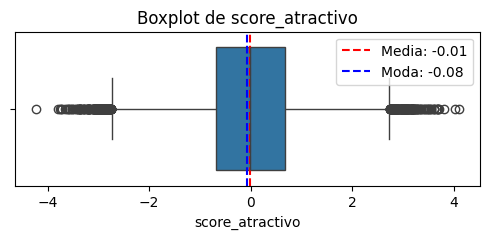


🏁 REVISIÓN EDA FINALIZADA


In [3]:
eda(df1)

In [23]:
eda(df2)

📐 VISIÓN GENERAL DEL DATASET
Vista inicial (primeras 5 filas):


,Name,Review,Rating,#ThumbsUp,Date&Time,App
0,linah sibanda,On this app i cant find a partner,5,0,18-02-2022 01:19,Tinder
1,Norman Johnson,Tinder would be so much better if we could spe...,3,0,18-02-2022 01:16,Tinder
2,David Hume,Still doesn't correctly notify matches or mess...,1,0,18-02-2022 01:11,Tinder
3,Last 1 Standing,"Got banned because I updated my bio to say ""I ...",2,0,18-02-2022 01:11,Tinder
4,Arthur Magamedov,Love it!,5,0,18-02-2022 01:06,Tinder


Dimensiones: 681994 filas × 6 columnas

Información general (dtypes, nulos, memoria):
<class 'pandas.core.frame.DataFrame'>
Index: 681994 entries, 0 to 52993
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Name       681987 non-null  object
 1   Review     680609 non-null  object
 2   Rating     681994 non-null  int64 
 3   #ThumbsUp  681994 non-null  int64 
 4   Date&Time  681994 non-null  object
 5   App        681994 non-null  object
dtypes: int64(2), object(4)
memory usage: 36.4+ MB

🚩 FLAG: duplicados - Filas duplicadas: 0 (0.00%)
----------------------------------------------------------------------
🚑 CALIDAD DE COLUMNAS


,Tipo,Nulos,% Nulos,Valores Únicos,% Cardinalidad
Review,object,1385,0.2,518393,76.01
Name,object,7,0.0,554761,81.34
Rating,int64,0,0.0,6,0.00
#ThumbsUp,int64,0,0.0,683,0.10
Date&Time,object,0,0.0,619021,90.77
App,object,0,0.0,3,0.00



🚩 FLAG: nulos - Clasificación por umbral (% nulos)
  🟢 Bajo (≤ 5%):
    - Review (0.20%)
  🟡 Moderado (5%–20%):
    - Ninguna
  🔴 Alto (> 20%):
    - Ninguna

🔤 NULOS EN VARIABLES CATEGÓRICAS

📌 Name — 🚩 FLAG: nulos_categorica (0.00%)


...


📌 Date&Time — 619021 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,18-02-2022 01:19
1,18-02-2022 01:16
2,18-02-2022 01:11
3,18-02-2022 01:06
4,18-02-2022 00:57
5,18-02-2022 00:52
6,18-02-2022 00:37
7,18-02-2022 00:28
8,18-02-2022 00:23
9,18-02-2022 00:17



📌 App — 3 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,Tinder
1,Bumble
2,Hinge



⚠️ OUTLIERS — Método IQR (1.5x)

🏁 REVISIÓN EDA FINALIZADA
